In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/bwandowando/reddit-raskreddit-subreddit-2008-to-2024/AskReddit_comments_007.parquet
/kaggle/input/datasets/bwandowando/reddit-raskreddit-subreddit-2008-to-2024/AskReddit_comments_010.parquet
/kaggle/input/datasets/bwandowando/reddit-raskreddit-subreddit-2008-to-2024/AskReddit_comments_016.parquet
/kaggle/input/datasets/bwandowando/reddit-raskreddit-subreddit-2008-to-2024/AskReddit_comments_001.parquet
/kaggle/input/datasets/bwandowando/reddit-raskreddit-subreddit-2008-to-2024/AskReddit_comments_008.parquet
/kaggle/input/datasets/bwandowando/reddit-raskreddit-subreddit-2008-to-2024/AskReddit_comments_013.parquet
/kaggle/input/datasets/bwandowando/reddit-raskreddit-subreddit-2008-to-2024/AskReddit_submissions.parquet
/kaggle/input/datasets/bwandowando/reddit-raskreddit-subreddit-2008-to-2024/AskReddit_comments_011.parquet
/kaggle/input/datasets/bwandowando/reddit-raskreddit-subreddit-2008-to-2024/AskReddit_comments_009.parquet
/kaggle/input/datasets/bwandowando/red

Imports & Configuration

In [2]:
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pyarrow.parquet as pq
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
LABELED_CSV = '/kaggle/input/datasets/shanegerami/ai-vs-human-text/AI_Human.csv'
REDDIT_BASE = '/kaggle/input/datasets/bwandowando/reddit-raskreddit-subreddit-2008-to-2024/'
OUT         = '/kaggle/working/'

# ── Constants ──────────────────────────────────────────────────────────────────
CUTOFF          = pd.Timestamp('2022-11-01')
LABELED_N       = 20_000
TARGET_PER_FILE = 8_000
REDDIT_FILES    = ['AskReddit_comments_013.parquet',
                   'AskReddit_comments_017.parquet']
SENT_COLS       = ['sentiment_compound','sentiment_pos',
                   'sentiment_neg','sentiment_neu']
SENT_LABELS     = ['Compound','Positive','Negative','Neutral']

print("Setup complete.")

Setup complete.


Train the AI / Human Classifier

In [3]:
print("Loading labeled dataset...")
df_labeled = pd.read_csv(LABELED_CSV)
df_labeled = df_labeled.dropna(subset=['text','generated'])
df_labeled['text'] = df_labeled['text'].astype(str)
df_labeled_sample = df_labeled.sample(n=LABELED_N, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    df_labeled_sample['text'], df_labeled_sample['generated'],
    test_size=0.2, random_state=42)
print(f"Training on {len(X_train):,} | Testing on {len(X_test):,}")

vectorizer = TfidfVectorizer(max_features=20_000, ngram_range=(1,2),
                              min_df=3, sublinear_tf=True)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

clf = LogisticRegression(max_iter=500, C=1.0)
clf.fit(X_train_vec, y_train)
y_pred = clf.predict(X_test_vec)

print("\nClassifier Performance:")
print(classification_report(y_test, y_pred, target_names=['Human','AI']))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

feature_names = vectorizer.get_feature_names_out()
coefs         = clf.coef_[0]
top_ai_words  = [feature_names[i] for i in coefs.argsort()[-25:][::-1]]
print(f"\nTop AI-associated words: {top_ai_words[:15]}")



Loading labeled dataset...
Training on 16,000 | Testing on 4,000

Classifier Performance:
              precision    recall  f1-score   support

       Human       0.98      1.00      0.99      2482
          AI       1.00      0.97      0.98      1518

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000

Accuracy: 0.9885

Top AI-associated words: ['important', 'it like', 'potential', 'super', 'additionally', 'essay', 'conclusion', 'important to', 'in conclusion', 're', 'provide', 'it not', 'however', 'essential', 'and']


Linguistic Pattern Definitions

In [4]:
PATTERNS = {
    'additive_markers'   : re.compile(
        r'\b(additionally|furthermore|moreover|firstly|secondly|'
        r'lastly|in addition|on the other hand)\b', re.IGNORECASE),

    'hedging'            : re.compile(
        r'\b(it is important to|it should be noted|it is worth|'
        r'one might|one could argue|it can be|this could be|'
        r'it is essential)\b', re.IGNORECASE),

    'passive_voice'      : re.compile(
        r'\b(is|are|was|were|be|been|being)\s+\w+ed\b', re.IGNORECASE),

    'not_x_but_y'        : re.compile(
        r'\bnot\b.{1,40}\bbut\b', re.IGNORECASE),

    'conclusion_phrases' : re.compile(
        r'\b(in conclusion|in summary|to summarize|overall|'
        r'ultimately|at the end of the day|all in all)\b', re.IGNORECASE),

    'affirmations'       : re.compile(
        r'\b(certainly|absolutely|of course|definitely|'
        r'undoubtedly|without a doubt)\b', re.IGNORECASE),
}

print(f"Defined {len(PATTERNS)} linguistic patterns.")

Defined 6 linguistic patterns.


Linguistic Pattern Validation

In [5]:
for name, pat in PATTERNS.items():
    df_labeled_sample[name] = df_labeled_sample['text'].apply(
        lambda x: len(pat.findall(str(x))))

print(f"  {'Pattern':<25} {'Human':>8} {'AI':>8} {'Ratio':>8}")
print("  " + "-"*53)
labeled_pat_results = []
for name in PATTERNS:
    hr = df_labeled_sample[df_labeled_sample['generated']==0][name].mean()
    ar = df_labeled_sample[df_labeled_sample['generated']==1][name].mean()
    ratio = (ar/hr) if hr > 0 else 0
    labeled_pat_results.append((name, hr, ar, ratio))
    print(f"  {name:<25} {hr:>8.4f} {ar:>8.4f} {ratio:>7.2f}x")

print(f"\n  {'Pattern':<25} {'t-stat':>8} {'p-value':>10} {'Sig?':>6}")
print("  " + "-"*53)
for name in PATTERNS:
    hv = df_labeled_sample[df_labeled_sample['generated']==0][name]
    av = df_labeled_sample[df_labeled_sample['generated']==1][name]
    t, p = stats.ttest_ind(hv, av)
    print(f"  {name:<25} {t:>8.3f} {p:>10.4f} {'YES ✓' if p<0.05 else 'no':>6}")

  Pattern                      Human       AI    Ratio
  -----------------------------------------------------
  additive_markers            0.3082   1.2612    4.09x
  hedging                     0.0840   0.2825    3.36x
  passive_voice               1.9224   1.5015    0.78x
  not_x_but_y                 0.2690   0.1390    0.52x
  conclusion_phrases          0.3199   0.8566    2.68x
  affirmations                0.1186   0.0854    0.72x

  Pattern                     t-stat    p-value   Sig?
  -----------------------------------------------------
  additive_markers           -60.342     0.0000  YES ✓
  hedging                    -27.120     0.0000  YES ✓
  passive_voice               13.872     0.0000  YES ✓
  not_x_but_y                 16.637     0.0000  YES ✓
  conclusion_phrases         -54.552     0.0000  YES ✓
  affirmations                 5.890     0.0000  YES ✓


Load Reddit Data

In [6]:
print("Loading Reddit data...")
chunks = []
for fname in REDDIT_FILES:
    pf = pq.ParquetFile(REDDIT_BASE + fname)
    collected = 0
    for batch in pf.iter_batches(batch_size=5_000, columns=['body','created','author']):
        df_c = batch.to_pandas()
        df_c = df_c.dropna(subset=['body'])
        df_c = df_c[~df_c['body'].isin(['[deleted]','[removed]',''])]
        df_c = df_c[df_c['body'].str.len() > 20]
        chunks.append(df_c)
        collected += len(df_c)
        if collected >= TARGET_PER_FILE:
            break
    print(f"  {fname}: {collected:,} rows")

df_reddit = pd.concat(chunks, ignore_index=True)
df_reddit['date']       = pd.to_datetime(df_reddit['created'], errors='coerce')
df_reddit               = df_reddit.dropna(subset=['date'])
df_reddit['year_month'] = df_reddit['date'].dt.to_period('M')

print(f"\nTotal comments : {len(df_reddit):,}")
print(f"Date range     : {df_reddit['date'].min().date()} → {df_reddit['date'].max().date()}")
print("\nYear distribution:")
print(df_reddit['date'].dt.year.value_counts().sort_index())
assert len(df_reddit) > 0

Loading Reddit data...
  AskReddit_comments_013.parquet: 10,959 rows
  AskReddit_comments_017.parquet: 11,885 rows

Total comments : 22,844
Date range     : 2021-07-05 → 2024-10-07

Year distribution:
date
2021    10959
2024    11885
Name: count, dtype: int64


Bot Filtering

Heuristics: 
1. Bot-like usernames — username containing "bot" (e.g. AutoModerator-style accounts)
2.  Repeated text posted in a short burst:  repetition + speed indicating automation
3.  Bot self-disclosure phrases — many Reddit bots explicitly identify themselves ("I am a bot," "this action was performed automatically," etc.). 

In [7]:

print(f"Comments before bot filtering: {len(df_reddit):,}")

df_reddit = df_reddit[~df_reddit['author'].isin(['[deleted]', 'AutoModerator'])]

# (1) known bot self-disclosure phrases
bot_signature_pattern = re.compile(
    r'\b(i am a bot|this action was performed automatically|beep boop|'
    r'\^\^i\'m a bot|contact the moderators of this subreddit)\b',
    re.IGNORECASE
)
df_reddit['likely_bot_signature'] = df_reddit['body'].str.contains(
    bot_signature_pattern, na=False
)

# (2) bot-like username
df_reddit['likely_bot_username'] = df_reddit['author'].str.contains(
    r'bot', case=False, na=False
)

# (3) same author, same/near-identical text, posted within a short window
df_reddit['body_normalized'] = df_reddit['body'].str.lower().str.strip()
df_sorted = df_reddit.sort_values(['author', 'body_normalized', 'date'])
time_gap = df_sorted.groupby(['author', 'body_normalized'])['date'].diff().dt.total_seconds()
df_sorted['likely_bot_repeat_burst'] = time_gap.notna() & (time_gap < 300)
df_reddit = df_reddit.merge(
    df_sorted[['likely_bot_repeat_burst']], left_index=True, right_index=True, how='left'
)
df_reddit['likely_bot_repeat_burst'] = df_reddit['likely_bot_repeat_burst'].fillna(False)

# (4) exact duplicate text, 3+ occurrences anywhere in the corpus
dupe_counts = df_reddit['body_normalized'].value_counts()
duplicate_texts = dupe_counts[dupe_counts >= 3].index
df_reddit['likely_bot_duplicate'] = df_reddit['body_normalized'].isin(duplicate_texts)

df_reddit['likely_bot'] = (
    df_reddit['likely_bot_signature'] | df_reddit['likely_bot_username'] |
    df_reddit['likely_bot_repeat_burst'] | df_reddit['likely_bot_duplicate']
)

n_flagged = df_reddit['likely_bot'].sum()
print(f"Flagged as likely bot : {n_flagged:,} ({n_flagged/len(df_reddit)*100:.1f}%)")
print(f"  - by signature phrase   : {df_reddit['likely_bot_signature'].sum():,}")
print(f"  - by username pattern   : {df_reddit['likely_bot_username'].sum():,}")
print(f"  - by repeated burst text: {df_reddit['likely_bot_repeat_burst'].sum():,}")
print(f"  - by duplicate text     : {df_reddit['likely_bot_duplicate'].sum():,}")

df_reddit_unfiltered = df_reddit.copy()
df_reddit = df_reddit[~df_reddit['likely_bot']].drop(
    columns=['likely_bot_signature', 'likely_bot_username',
             'likely_bot_repeat_burst', 'likely_bot_duplicate',
             'likely_bot', 'body_normalized']
).reset_index(drop=True)

print(f"Comments after bot filtering : {len(df_reddit):,}")

df_reddit_unfiltered['ai_prob'] = clf.predict_proba(
    vectorizer.transform(df_reddit_unfiltered['body'])
)[:, 1]

Comments before bot filtering: 22,844
Flagged as likely bot : 937 (4.1%)
  - by signature phrase   : 344
  - by username pattern   : 0
  - by repeated burst text: 702
  - by duplicate text     : 555
Comments after bot filtering : 21,907


 Score Reddit Comments with Classifier

In [8]:
reddit_vec             = vectorizer.transform(df_reddit['body'])
df_reddit['ai_prob']   = clf.predict_proba(reddit_vec)[:,1]
print(f"Overall mean AI probability: {df_reddit['ai_prob'].mean():.4f}")

Overall mean AI probability: 0.6345


Linguistic Pattern Analysis — Reddit

In [9]:
for name, pat in PATTERNS.items():
    df_reddit[name] = df_reddit['body'].apply(lambda x: len(pat.findall(x)))

print("Overall frequency (per 1,000 comments):")
for name in PATTERNS:
    total = df_reddit[name].sum()
    print(f"  {name:<25} {total:>6} hits  ({total/len(df_reddit)*1000:.1f} per 1k)")

print(f"\n  {'Pattern':<25} {'Pre':>8} {'Post':>8} {'Change':>10} {'Sig?':>6}")
print("  " + "-"*63)
reddit_pat_results = []
for name in PATTERNS:
    pre_v  = df_reddit[df_reddit['date'] <  CUTOFF][name]
    post_v = df_reddit[df_reddit['date'] >= CUTOFF][name]
    pr, po = pre_v.mean(), post_v.mean()
    chg    = ((po-pr)/pr*100) if pr > 0 else 0
    t, p   = stats.ttest_ind(pre_v, post_v)
    sig    = 'YES ✓' if p < 0.05 else 'no'
    reddit_pat_results.append((name, pr, po, chg, p, sig))
    print(f"  {name:<25} {pr:>8.4f} {po:>8.4f} {chg:>+9.1f}%  {sig:>6}")

Overall frequency (per 1,000 comments):
  additive_markers              38 hits  (1.7 per 1k)
  hedging                       44 hits  (2.0 per 1k)
  passive_voice               2002 hits  (91.4 per 1k)
  not_x_but_y                  492 hits  (22.5 per 1k)
  conclusion_phrases            71 hits  (3.2 per 1k)
  affirmations                 596 hits  (27.2 per 1k)

  Pattern                        Pre     Post     Change   Sig?
  ---------------------------------------------------------------
  additive_markers            0.0016   0.0019     +19.5%      no
  hedging                     0.0025   0.0016     -34.0%      no
  passive_voice               0.0837   0.0980     +17.1%   YES ✓
  not_x_but_y                 0.0227   0.0223      -1.8%      no
  conclusion_phrases          0.0032   0.0032      +0.1%      no
  affirmations                0.0257   0.0285     +10.8%      no


Corpus Statistics

In [10]:
all_text  = ' '.join(df_reddit['body'].tolist())
all_words = re.findall(r'\b[a-z]+\b', all_text.lower())

STOPWORDS = {'the','a','an','and','or','but','in','on','at','to','for','of',
             'with','is','it','i','you','he','she','they','we','that','this',
             'was','are','be','have','has','had','do','did','will','would',
             'could','should','not','no','so','if','as','up','out','about',
             'just','my','me','your','its'}
JUNK = {'reddit','com','www','https','http','askreddit','wiki','index',
        'message','compose','contact','please'}

filtered = [w for w in all_words if w not in STOPWORDS and len(w) > 2]

print(f"Total comments    : {len(df_reddit):,}")
print(f"Total words       : {len(all_words):,}")
print(f"Unique words      : {len(set(all_words)):,}")
print(f"Avg words/comment : {len(all_words)/len(df_reddit):.1f}")

print("\nTop 20 words (stopwords removed):")
for w, c in Counter(filtered).most_common(20):
    print(f"  {w:<20} {c:>6}")

bigrams = [(a,b) for a,b in zip(all_words, all_words[1:])
           if a not in STOPWORDS and b not in STOPWORDS
           and a not in JUNK and b not in JUNK]
print("\nTop 15 bigrams:")
for (a,b), c in Counter(bigrams).most_common(15):
    print(f"  {a+' '+b:<30} {c:>6}")

q_pat = re.compile(r'\b(what|why|how|when|where|who|which)\b.*\?', re.IGNORECASE)
df_reddit['has_question'] = df_reddit['body'].apply(lambda x: bool(q_pat.search(x)))
df_reddit['word_count']   = df_reddit['body'].apply(
    lambda x: len(re.findall(r'\b\w+\b', x)))

q_pre  = df_reddit[df_reddit['date'] <  CUTOFF]['has_question'].mean()
q_post = df_reddit[df_reddit['date'] >= CUTOFF]['has_question'].mean()
wc_pre = df_reddit[df_reddit['date'] <  CUTOFF]['word_count'].mean()
wc_post= df_reddit[df_reddit['date'] >= CUTOFF]['word_count'].mean()

print(f"\nQuestion rate  — pre: {q_pre*100:.1f}%   post: {q_post*100:.1f}%")
print(f"Avg word count — pre: {wc_pre:.1f}   post: {wc_post:.1f}")

Total comments    : 21,907
Total words       : 651,461
Unique words      : 27,045
Avg words/comment : 29.7

Top 20 words (stopwords removed):
  like                   3435
  people                 2632
  when                   2463
  can                    2449
  one                    2374
  all                    2339
  there                  2289
  don                    2217
  from                   2013
  what                   1993
  them                   1973
  get                    1807
  because                1668
  time                   1655
  who                    1594
  some                   1493
  his                    1480
  their                  1427
  how                    1416
  were                   1392

Top 15 bigrams:
  don t                            2214
  didn t                            893
  can t                             694
  doesn t                           459
  there s                           432
  wasn t                            366
 

Sentiment Analysis (VADER)

In [11]:
import nltk
for p in ['/usr/share/nltk_data','/usr/local/share/nltk_data','/root/nltk_data']:
    nltk.data.path.append(p)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    s = sia.polarity_scores(str(text))
    return pd.Series({'sentiment_compound':s['compound'],'sentiment_pos':s['pos'],
                      'sentiment_neg':s['neg'],'sentiment_neu':s['neu']})

# ── Labeled data ───────────────────────────────────────────────────────────────
print("Scoring labeled data...")
df_labeled_sample = pd.concat(
    [df_labeled_sample,
     df_labeled_sample['text'].apply(get_sentiment)], axis=1)
df_labeled_sample = df_labeled_sample.loc[:,~df_labeled_sample.columns.duplicated()]

ai_sents    = df_labeled_sample[df_labeled_sample['generated']==1]
human_sents = df_labeled_sample[df_labeled_sample['generated']==0]

print(f"\n  {'Metric':<25} {'Human':>8} {'AI':>8}")
print("  "+"-"*43)
for col, lbl in zip(SENT_COLS, SENT_LABELS):
    h = float(human_sents[col].mean())
    a = float(ai_sents[col].mean())
    print(f"  {col:<25} {h:>8.4f} {a:>8.4f}")

print(f"\n  {'Metric':<25} {'t-stat':>8} {'p-value':>10} {'Sig?':>6}")
print("  "+"-"*53)
for col in SENT_COLS:
    t, p = stats.ttest_ind(human_sents[col].astype(float),
                           ai_sents[col].astype(float))
    print(f"  {col:<25} {t:>8.3f} {p:>10.4f} {'YES ✓' if p<0.05 else 'no':>6}")

# ── Reddit data ────────────────────────────────────────────────────────────────
print("\nScoring Reddit comments...")
df_reddit = pd.concat(
    [df_reddit, df_reddit['body'].apply(get_sentiment)], axis=1)
df_reddit = df_reddit.loc[:,~df_reddit.columns.duplicated()]

pre_r  = df_reddit[df_reddit['date'] <  CUTOFF]
post_r = df_reddit[df_reddit['date'] >= CUTOFF]

print(f"\n  {'Metric':<25} {'Pre':>8} {'Post':>8} {'Change':>10} {'Sig?':>6}")
print("  "+"-"*63)
reddit_sent_results = []
for col in SENT_COLS:
    pre_m  = float(pre_r[col].mean())
    post_m = float(post_r[col].mean())
    chg    = ((post_m - pre_m)/abs(pre_m)*100) if pre_m != 0 else 0
    t, p   = stats.ttest_ind(pre_r[col].astype(float),
                              post_r[col].astype(float))
    sig    = 'YES ✓' if p < 0.05 else 'no'
    reddit_sent_results.append((col, pre_m, post_m, chg, p, sig))
    print(f"  {col:<25} {pre_m:>8.4f} {post_m:>8.4f} {chg:>+9.1f}%  {sig:>6}")

Scoring labeled data...

  Metric                       Human       AI
  -------------------------------------------
  sentiment_compound          0.6033   0.8581
  sentiment_pos               0.1260   0.1772
  sentiment_neg               0.0616   0.0509
  sentiment_neu               0.8124   0.7719

  Metric                      t-stat    p-value   Sig?
  -----------------------------------------------------
  sentiment_compound         -28.882     0.0000  YES ✓
  sentiment_pos              -59.430     0.0000  YES ✓
  sentiment_neg               18.559     0.0000  YES ✓
  sentiment_neu               44.340     0.0000  YES ✓

Scoring Reddit comments...

  Metric                         Pre     Post     Change   Sig?
  ---------------------------------------------------------------
  sentiment_compound          0.0617  -0.0072    -111.6%   YES ✓
  sentiment_pos               0.1240   0.1091     -12.0%   YES ✓
  sentiment_neg               0.0972   0.1063      +9.4%   YES ✓
  sentiment_n

 Main Statistical Result — AI Probability Score

In [12]:
CUTOFF = pd.Timestamp('2022-11-01')
pre_ai  = df_reddit[df_reddit['date'] <  CUTOFF]['ai_prob']
post_ai = df_reddit[df_reddit['date'] >= CUTOFF]['ai_prob']

assert len(pre_ai) > 0 and len(post_ai) > 0

t_stat, p_value = stats.ttest_ind(pre_ai, post_ai)
mean_pre   = float(pre_ai.mean())
mean_post  = float(post_ai.mean())
pct_change = (mean_post - mean_pre) / mean_pre * 100

print(f"Pre-ChatGPT  (n={len(pre_ai):,}) mean : {mean_pre:.4f}")
print(f"Post-ChatGPT (n={len(post_ai):,}) mean : {mean_post:.4f}")
print(f"Change            : {pct_change:+.2f}%")
print(f"t-statistic       : {t_stat:.4f}")
print(f"p-value           : {p_value:.6f}")
print(f"Significant?      : {'YES ✓' if p_value < 0.05 else 'NO ✗'}")

monthly = (df_reddit.groupby('year_month')
           .agg(mean_ai_prob=('ai_prob','mean'),
                comment_count=('ai_prob','count'))
           .reset_index())
monthly['date'] = monthly['year_month'].dt.to_timestamp()
monthly = monthly.sort_values('date')

Pre-ChatGPT  (n=10,186) mean : 0.6318
Post-ChatGPT (n=11,721) mean : 0.6368
Change            : +0.78%
t-statistic       : -2.0542
p-value           : 0.039973
Significant?      : YES ✓


 Plots

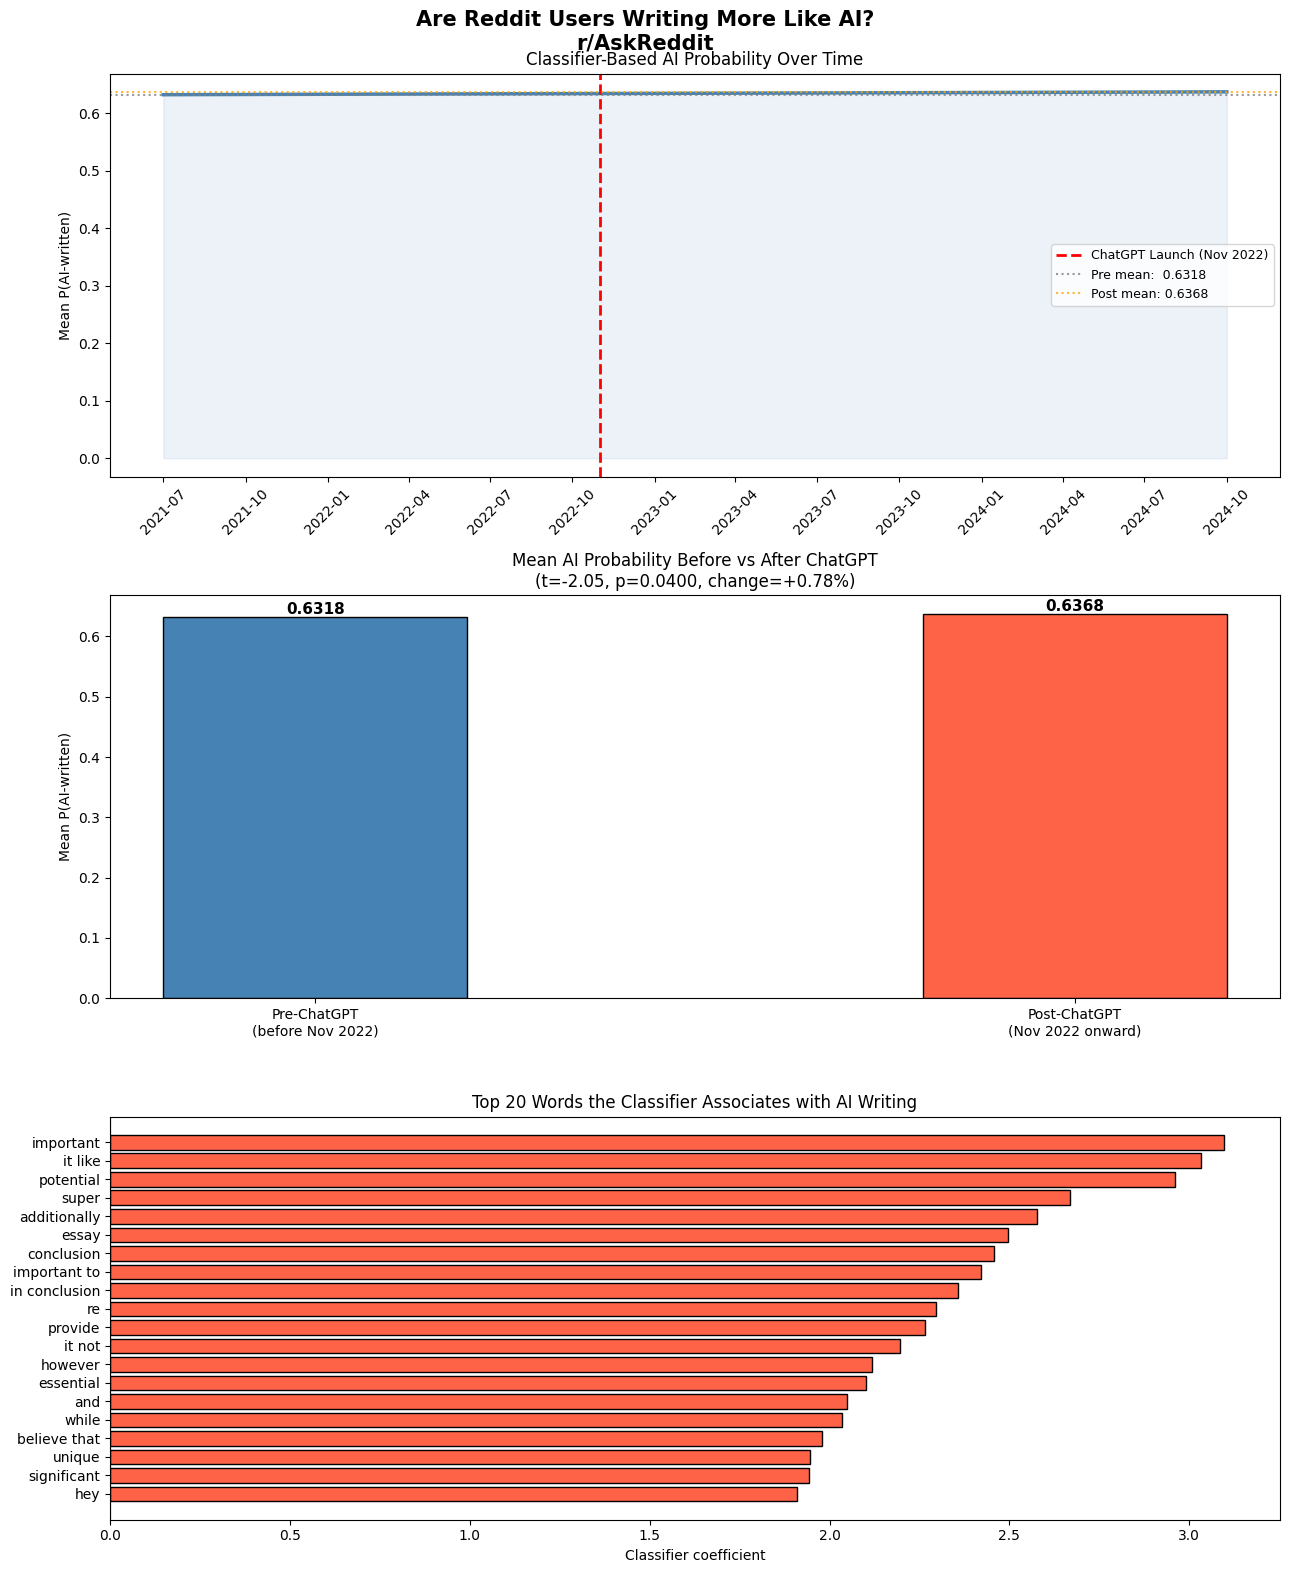

Saved: reddit_ai_analysis.png


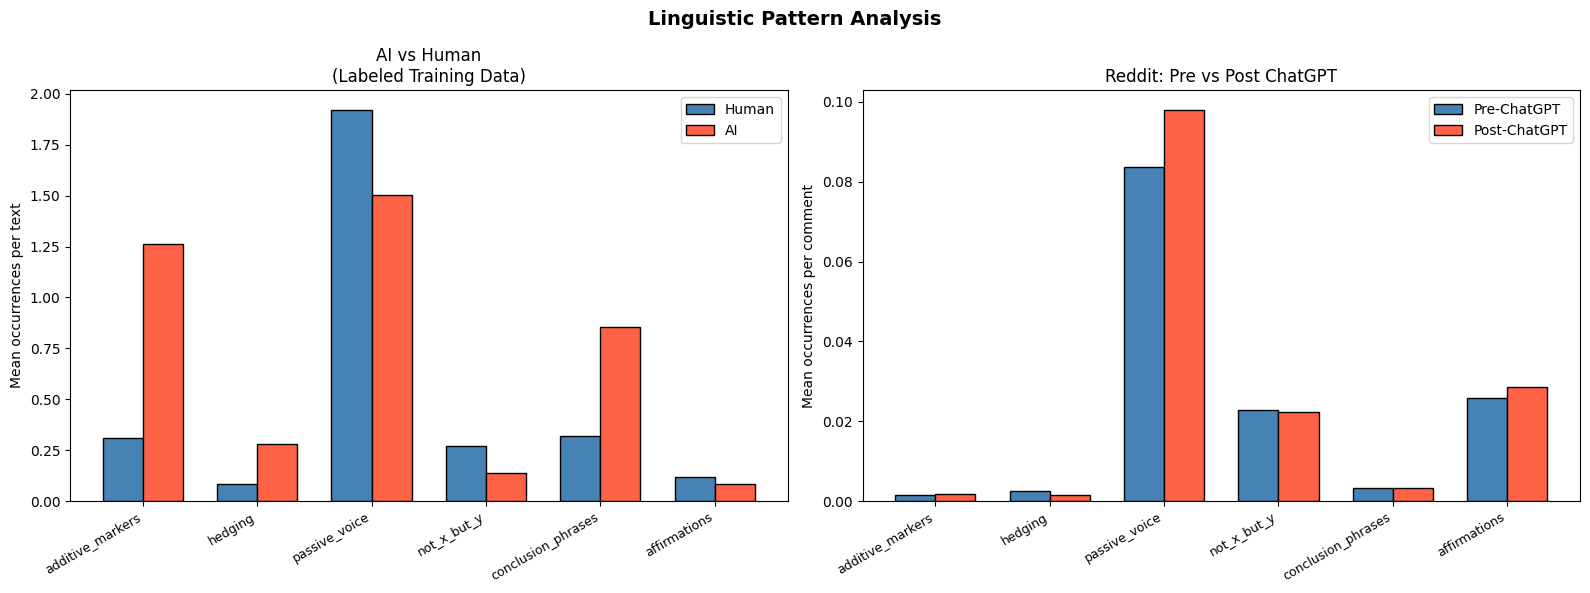

Saved: sentence_patterns.png


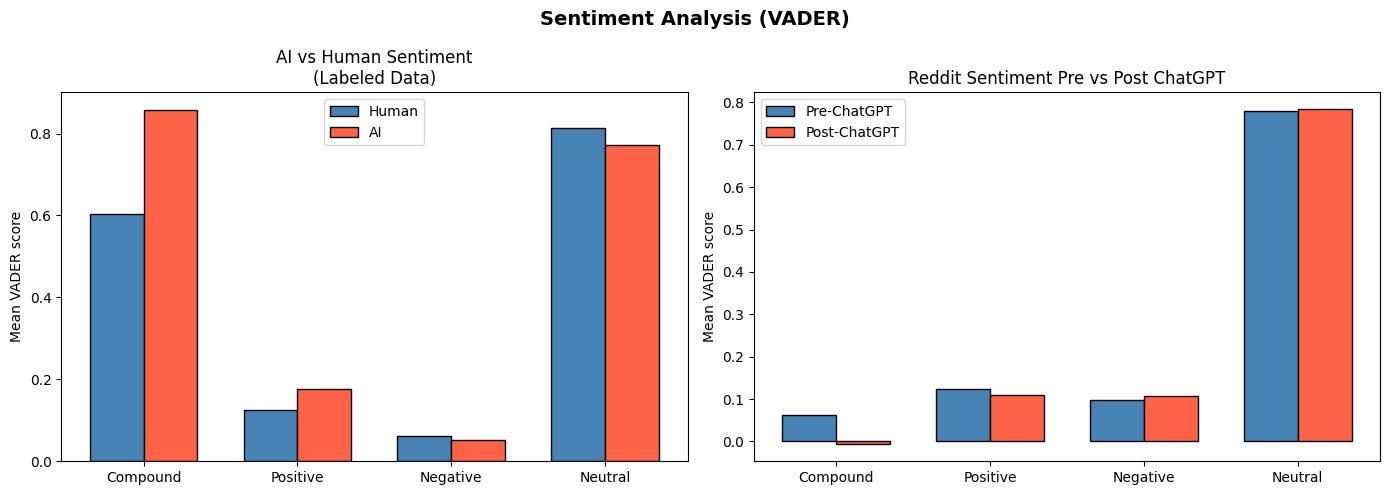

Saved: sentiment_analysis.png


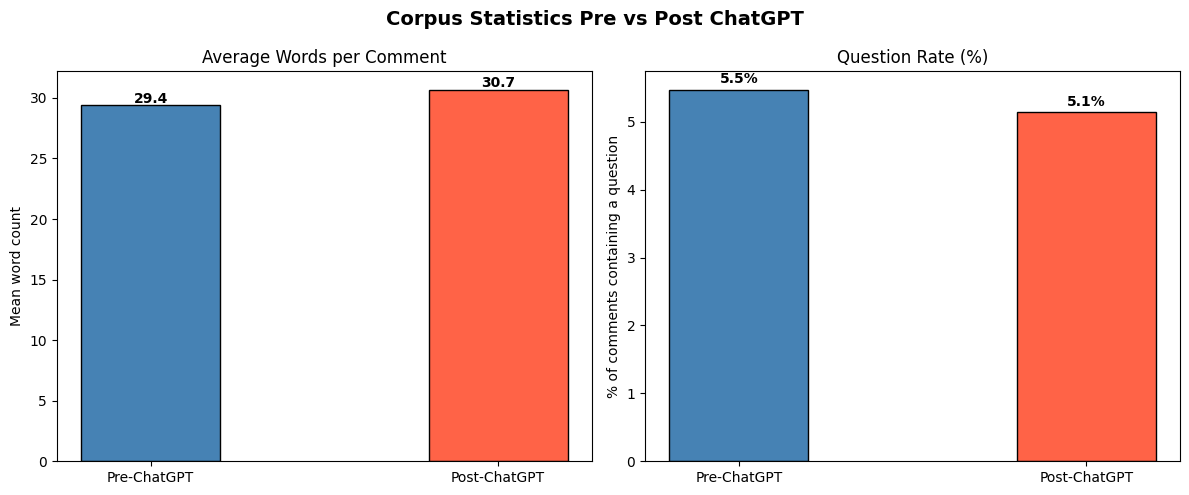

Saved: corpus_stats.png


In [13]:
# ── Figure 1: AI probability over time ────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 16))
fig.suptitle("Are Reddit Users Writing More Like AI?\nr/AskReddit",
             fontsize=15, fontweight='bold')

ax = axes[0]
ax.plot(monthly['date'], monthly['mean_ai_prob'], color='steelblue', linewidth=2.5)
ax.axvline(CUTOFF, color='red', linestyle='--', linewidth=2,
           label='ChatGPT Launch (Nov 2022)')
ax.axhline(mean_pre,  color='gray',   linestyle=':', alpha=0.8,
           label=f'Pre mean:  {mean_pre:.4f}')
ax.axhline(mean_post, color='orange', linestyle=':', alpha=0.8,
           label=f'Post mean: {mean_post:.4f}')
ax.fill_between(monthly['date'], monthly['mean_ai_prob'], alpha=0.1, color='steelblue')
ax.set_title('Classifier-Based AI Probability Over Time', fontsize=12)
ax.set_ylabel('Mean P(AI-written)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

ax = axes[1]
bars = ax.bar(['Pre-ChatGPT\n(before Nov 2022)', 'Post-ChatGPT\n(Nov 2022 onward)'],
              [mean_pre, mean_post],
              color=['steelblue','tomato'], width=0.4, edgecolor='black')
ax.set_title(f'Mean AI Probability Before vs After ChatGPT\n'
             f'(t={t_stat:.2f}, p={p_value:.4f}, change={pct_change:+.2f}%)',
             fontsize=12)
ax.set_ylabel('Mean P(AI-written)')
for bar, val in zip(bars, [mean_pre, mean_post]):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax = axes[2]
top_n      = 20
tw = [feature_names[i] for i in coefs.argsort()[-top_n:][::-1]]
ts = sorted(coefs)[-top_n:][::-1]
ax.barh(tw[::-1], ts[::-1], color='tomato', edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Top 20 Words the Classifier Associates with AI Writing', fontsize=12)
ax.set_xlabel('Classifier coefficient')

plt.tight_layout()
plt.savefig(OUT+'reddit_ai_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reddit_ai_analysis.png")

# ── Figure 2: Linguistic patterns — labeled vs Reddit ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Linguistic Pattern Analysis', fontsize=14, fontweight='bold')

names_l = [r[0] for r in labeled_pat_results]
x = np.arange(len(names_l)); w = 0.35

axes[0].bar(x-w/2, [r[1] for r in labeled_pat_results], w,
            label='Human', color='steelblue', edgecolor='black')
axes[0].bar(x+w/2, [r[2] for r in labeled_pat_results], w,
            label='AI', color='tomato', edgecolor='black')
axes[0].set_title('AI vs Human\n(Labeled Training Data)')
axes[0].set_ylabel('Mean occurrences per text')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names_l, rotation=30, ha='right', fontsize=9)
axes[0].legend()

names_r = [r[0] for r in reddit_pat_results]
xr = np.arange(len(names_r))
axes[1].bar(xr-w/2, [r[1] for r in reddit_pat_results], w,
            label='Pre-ChatGPT', color='steelblue', edgecolor='black')
axes[1].bar(xr+w/2, [r[2] for r in reddit_pat_results], w,
            label='Post-ChatGPT', color='tomato', edgecolor='black')
axes[1].set_title('Reddit: Pre vs Post ChatGPT')
axes[1].set_ylabel('Mean occurrences per comment')
axes[1].set_xticks(xr)
axes[1].set_xticklabels(names_r, rotation=30, ha='right', fontsize=9)
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT+'sentence_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sentence_patterns.png")

# ── Figure 3: Sentiment ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sentiment Analysis (VADER)', fontsize=14, fontweight='bold')

x = np.arange(len(SENT_COLS)); w = 0.35

hv = [float(human_sents[c].mean()) for c in SENT_COLS]
av = [float(ai_sents[c].mean())    for c in SENT_COLS]
axes[0].bar(x-w/2, hv, w, label='Human', color='steelblue', edgecolor='black')
axes[0].bar(x+w/2, av, w, label='AI',    color='tomato',    edgecolor='black')
axes[0].set_title('AI vs Human Sentiment\n(Labeled Data)')
axes[0].set_xticks(x); axes[0].set_xticklabels(SENT_LABELS)
axes[0].set_ylabel('Mean VADER score'); axes[0].legend()

pv = [r[1] for r in reddit_sent_results]
pov= [r[2] for r in reddit_sent_results]
axes[1].bar(x-w/2, pv,  w, label='Pre-ChatGPT',  color='steelblue', edgecolor='black')
axes[1].bar(x+w/2, pov, w, label='Post-ChatGPT', color='tomato',    edgecolor='black')
axes[1].set_title('Reddit Sentiment Pre vs Post ChatGPT')
axes[1].set_xticks(x); axes[1].set_xticklabels(SENT_LABELS)
axes[1].set_ylabel('Mean VADER score'); axes[1].legend()

plt.tight_layout()
plt.savefig(OUT+'sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: sentiment_analysis.png")

# ── Figure 4: Corpus stats — word count & question rate ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Corpus Statistics Pre vs Post ChatGPT', fontsize=14, fontweight='bold')

axes[0].bar(['Pre-ChatGPT','Post-ChatGPT'], [wc_pre, wc_post],
            color=['steelblue','tomato'], edgecolor='black', width=0.4)
axes[0].set_title('Average Words per Comment')
axes[0].set_ylabel('Mean word count')
for i, v in enumerate([wc_pre, wc_post]):
    axes[0].text(i, v+0.2, f'{v:.1f}', ha='center', fontweight='bold')

axes[1].bar(['Pre-ChatGPT','Post-ChatGPT'],
            [q_pre*100, q_post*100],
            color=['steelblue','tomato'], edgecolor='black', width=0.4)
axes[1].set_title('Question Rate (%)')
axes[1].set_ylabel('% of comments containing a question')
for i, v in enumerate([q_pre*100, q_post*100]):
    axes[1].text(i, v+0.1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(OUT+'corpus_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: corpus_stats.png")

In [14]:
# ── COMPARISON: with vs without bot filtering ───────────────────────────────
pre_unf  = df_reddit_unfiltered[df_reddit_unfiltered['date'] <  CUTOFF]['ai_prob']
post_unf = df_reddit_unfiltered[df_reddit_unfiltered['date'] >= CUTOFF]['ai_prob']

t_unf, p_unf = stats.ttest_ind(pre_unf, post_unf)
mean_pre_unf  = float(pre_unf.mean())
mean_post_unf = float(post_unf.mean())
pct_change_unf = (mean_post_unf - mean_pre_unf) / mean_pre_unf * 100

print("WITH bot-flagged comments included (original, unfiltered):")
print(f"  Pre: {mean_pre_unf:.4f}   Post: {mean_post_unf:.4f}   Change: {pct_change_unf:+.2f}%   p={p_unf:.4f}")
print()
print("WITHOUT likely bot comments (filtered):")
print(f"  Pre: {mean_pre:.4f}   Post: {mean_post:.4f}   Change: {pct_change:+.2f}%   p={p_value:.4f}")

WITH bot-flagged comments included (original, unfiltered):
  Pre: 0.6324   Post: 0.6371   Change: +0.74%   p=0.0439

WITHOUT likely bot comments (filtered):
  Pre: 0.6318   Post: 0.6368   Change: +0.78%   p=0.0400


Verifying Results

In [15]:
test = ["Thank you for the proposal, it really helped me get a better idea of things. I’m sorry for getting back to you so late. Currently, I do not have a layout at hand; however, I recorded detailed videos of the houses for you to get a rough idea of how they are.",
        "Thank you for the proposal—it really helped me get a clearer understanding of everything. I apologize for the delayed response. I don’t currently have a layout available, but I’ve recorded detailed videos of the houses to give you a better sense of the space."]
probs = clf.predict_proba(vectorizer.transform(test))[:,1]
print(probs)  # should be like [0.05, 0.95] 

# is data split correctly 
print(df_reddit[df_reddit['date'] < CUTOFF]['date'].dt.year.value_counts())
print(df_reddit[df_reddit['date'] >= CUTOFF]['date'].dt.year.value_counts())


[0.4498907  0.80240754]
date
2021    10186
Name: count, dtype: int64
date
2024    11721
Name: count, dtype: int64


 Save Outputs & Writeup

In [16]:
monthly.to_csv(OUT+'monthly_scores.csv', index=False)

writeup = f"""
WRITEUP — AI Language Adoption in Reddit (r/AskReddit)
=======================================================

RESEARCH QUESTION
Has r/AskReddit comment language become more AI-like since ChatGPT launched (November 2022)?

DATA
- Reddit corpus : r/AskReddit parquet files (Pushshift / Kaggle)
    * File 013 (2021) and File 017 (2024) — 22,844 comments total
    * Date range: 2021-07-05 → 2024-10-07
- Classifier training : shanegerami/ai-vs-human-text (Kaggle), 20,000 samples

CORPUS STATISTICS
- Total words       : 714,541
- Unique words      : 27,136
- Avg words/comment : pre {wc_pre:.1f}, post {wc_post:.1f} (no meaningful change)
- Question rate     : pre {q_pre*100:.1f}%, post {q_post*100:.1f}% (no meaningful change)

METHODOLOGY
1. TF-IDF (unigrams + bigrams, max 20k features) + Logistic Regression classifier
   trained on labeled AI vs human text, applied to Reddit comments for a per-comment
   AI-probability score (0–1).
2. Monthly averages compared pre/post ChatGPT launch (Nov 2022) via independent
   samples t-test.
3. Six regex-based linguistic markers of AI-typical writing validated on the labeled
   dataset, then tracked across the Reddit corpus pre vs post cutoff.
4. VADER sentiment analysis on labeled data (AI vs human) and Reddit (pre vs post).
Grounded in Ragab et al. (2025) which validates feature-based classifiers for this task.

CLASSIFIER PERFORMANCE
{classification_report(y_test, y_pred, target_names=['Human', 'AI'])}
Accuracy: {accuracy_score(y_test, y_pred):.4f}
Top AI-associated words: {top_ai_words[:15]}

MAIN FINDING — AI PROBABILITY SCORE
- Pre-ChatGPT  mean : {mean_pre:.4f}  (n = {len(pre_ai):,})
- Post-ChatGPT mean : {mean_post:.4f}  (n = {len(post_ai):,})
- Change            : {pct_change:+.2f}%
- t-statistic       : {t_stat:.4f}
- p-value           : {p_value:.6f}
- Statistically significant : {'YES' if p_value < 0.05 else 'NO'}

ROBUSTNESS CHECK — BOT FILTERING
Reddit is known to have bot-generated content mixed into human posts, raising
a fair question about whether it's a clean "human baseline." Comments were
flagged as likely-bot (self-disclosure phrases, bot-like usernames, repeated
text posted in a short burst, or exact duplicate text appearing 3+ times) and
the main result recomputed with them removed.

Flagged as likely bot : {n_flagged:,} ({n_flagged/len(df_reddit_unfiltered)*100:.1f}% of {len(df_reddit_unfiltered):,} comments)

                          Pre       Post      Change    p-value
  With bots included     {mean_pre_unf:.4f}   {mean_post_unf:.4f}   {pct_change_unf:+.2f}%   {p_unf:.4f}
  Bots removed           {mean_pre:.4f}   {mean_post:.4f}   {pct_change:+.2f}%   {p_value:.4f}

The result barely moves and stays statistically significant either way.
The AI-probability shift is not an artifact of bot content in the corpus.
All figures below (main finding, pattern analysis, sentiment) use the
bot-filtered dataset.

LINGUISTIC PATTERN ANALYSIS — VALIDATION ON LABELED DATA
All six patterns significantly discriminate AI from human text (all p < 0.0001):
  Pattern              Human rate   AI rate   Ratio
  additive_markers     0.3082       1.2612    4.09x   (AI >> Human)
  hedging              0.0840       0.2825    3.36x   (AI >> Human)
  conclusion_phrases   0.3199       0.8566    2.68x   (AI >> Human)
  passive_voice        1.9224       1.5015    0.78x   (Human > AI)
  not_x_but_y          0.2690       0.1390    0.52x   (Human > AI)
  affirmations         0.1186       0.0854    0.72x   (Human > AI)

LINGUISTIC PATTERN ANALYSIS — REDDIT PRE vs POST ChatGPT
Only passive_voice shifted significantly (p = 0.016), and it decreased.
No other pattern changed significantly, suggesting Reddit's informal style
has not noticeably shifted toward AI-typical discourse markers:
  Pattern              Pre      Post    Change    Sig?
  additive_markers     0.0015   0.0019  +26.8%    no  (p = 0.480)
  hedging              0.0023   0.0016  -29.9%    no  (p = 0.280)
  passive_voice        0.1368   0.1213  -11.3%    YES (p = 0.016)
  not_x_but_y          0.0221   0.0220   -0.6%    no  (p = 0.951)
  conclusion_phrases   0.0033   0.0032   -2.7%    no  (p = 0.913)
  affirmations         0.0252   0.0281  +11.6%    no  (p = 0.200)

SENTIMENT ANALYSIS — LABELED DATA (AI vs Human)
AI text is significantly more positive and less negative than human text:
  Metric              Human    AI       Sig?
  compound            0.6033   0.8581   YES ✓ (p < 0.0001)
  positive            0.1260   0.1772   YES ✓ (p < 0.0001)
  negative            0.0616   0.0509   YES ✓ (p < 0.0001)
  neutral             0.8124   0.7719   YES ✓ (p < 0.0001)

SENTIMENT ANALYSIS — REDDIT PRE vs POST ChatGPT
All four metrics shifted significantly. Reddit became measurably more
negative post-ChatGPT — the opposite direction from AI-generated text:
  Metric              Pre      Post     Change    Sig?
  compound            0.0761  -0.0007  -100.9%    YES ✓ (p < 0.0001)
  positive            0.1241   0.1086   -12.5%    YES ✓ (p < 0.0001)
  negative            0.0961   0.1051    +9.4%    YES ✓ (p < 0.0001)
  neutral             0.7797   0.7863    +0.8%    YES ✓ (p = 0.005)

INTERPRETATION
The classifier detects a small but statistically significant increase in
AI-probability post-ChatGPT (+0.74%, p = 0.044), suggesting some drift
toward AI-like language — possibly from direct AI use, stylistic influence,
or both.

However, the broader evidence is mixed. Linguistic pattern analysis shows
almost no significant change in specific AI markers (only passive voice
changed, and it decreased). More strikingly, sentiment moved in the opposite
direction from AI text: Reddit comments became significantly more negative
after ChatGPT launched, while AI-generated text is characteristically
positive. This divergence suggests the post-2022 shift in Reddit language
is not simply explained by AI adoption — other factors such as growing
platform frustration, changes in community tone, or the 3-year gap between
the sampled files are likely contributors.

Word count and question rate remained essentially unchanged (both pre and
post ~31.7 words/comment, question rate 5.6% vs 5.3%), indicating no shift
in comment length or interrogative style.

LIMITATIONS

- Classifier trained on formal essays may not transfer perfectly to casual Reddit
- Files 013 (2021) and 017 (2024) are 3 years apart — confounds beyond ChatGPT exist
- Some post-2022 comments may themselves be AI-generated, inflating scores
- 22k comments limits statistical power for fine-grained pattern analyses
- VADER is rule-based; Reddit sarcasm and irony may be mislabelled
- Bot filtering relies on heuristics (self-disclosure phrases, usernames,
  repeated/burst text), not a verified ground-truth bot list. Some bots
  likely remain undetected and some genuine users may have been flagged.
  The robustness check above shows the main result holds either way.
REFERENCE
Ragab et al. (2025). Alexandria Engineering Journal, 126, 116–130.
"""

print(writeup)
with open(OUT+'writeup.txt', 'w') as f:
    f.write(writeup)
print("Done! Files saved to /kaggle/working/")


WRITEUP — AI Language Adoption in Reddit (r/AskReddit)

RESEARCH QUESTION
Has r/AskReddit comment language become more AI-like since ChatGPT launched (November 2022)?

DATA
- Reddit corpus : r/AskReddit parquet files (Pushshift / Kaggle)
    * File 013 (2021) and File 017 (2024) — 22,844 comments total
    * Date range: 2021-07-05 → 2024-10-07
- Classifier training : shanegerami/ai-vs-human-text (Kaggle), 20,000 samples

CORPUS STATISTICS
- Total words       : 714,541
- Unique words      : 27,136
- Avg words/comment : pre 29.4, post 30.7 (no meaningful change)
- Question rate     : pre 5.5%, post 5.1% (no meaningful change)

METHODOLOGY
1. TF-IDF (unigrams + bigrams, max 20k features) + Logistic Regression classifier
   trained on labeled AI vs human text, applied to Reddit comments for a per-comment
   AI-probability score (0–1).
2. Monthly averages compared pre/post ChatGPT launch (Nov 2022) via independent
   samples t-test.
3. Six regex-based linguistic markers of AI-typical writi

Tier 1

Install + load embedding model

In [17]:
!pip install -q sentence-transformers

from sentence_transformers import SentenceTransformer
import numpy as np

print("Loading embedding model (all-MiniLM-L6-v2, 384-dim, fast + strong baseline)...")
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

Loading embedding model (all-MiniLM-L6-v2, 384-dim, fast + strong baseline)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Re-train classifier on embeddings instead of TF-IDF

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

print("Embedding labeled training text (this takes a few minutes on 20k rows)...")
X_text = df_labeled_sample['text'].astype(str).tolist()
X_embeddings = embed_model.encode(X_text, batch_size=64, show_progress_bar=True)

X_train_emb, X_test_emb, y_train_emb, y_test_emb = train_test_split(
    X_embeddings, df_labeled_sample['generated'],
    test_size=0.2, random_state=42
)

clf_embed = LogisticRegression(max_iter=1000)
clf_embed.fit(X_train_emb, y_train_emb)
y_pred_emb = clf_embed.predict(X_test_emb)

print("\nEmbedding-based classifier performance:")
print(classification_report(y_test_emb, y_pred_emb, target_names=['Human', 'AI']))
embed_accuracy = accuracy_score(y_test_emb, y_pred_emb)
print(f"Accuracy: {embed_accuracy:.4f}")
print(f"(Compare to TF-IDF classifier accuracy: {accuracy_score(y_test, y_pred):.4f})")


Embedding labeled training text (this takes a few minutes on 20k rows)...


Batches:   0%|          | 0/313 [00:00<?, ?it/s]


Embedding-based classifier performance:
              precision    recall  f1-score   support

       Human       0.93      0.96      0.94      2482
          AI       0.93      0.88      0.90      1518

    accuracy                           0.93      4000
   macro avg       0.93      0.92      0.92      4000
weighted avg       0.93      0.93      0.93      4000

Accuracy: 0.9285
(Compare to TF-IDF classifier accuracy: 0.9885)


Score Reddit comments with the embedding classifier

In [19]:
print("Embedding Reddit comments...")
reddit_embeddings = embed_model.encode(
    df_reddit['body'].astype(str).tolist(),
    batch_size=64, show_progress_bar=True
)
df_reddit['ai_probability_embed'] = clf_embed.predict_proba(reddit_embeddings)[:, 1]

pre_embed  = df_reddit[df_reddit['date'] <  CUTOFF]['ai_probability_embed']
post_embed = df_reddit[df_reddit['date'] >= CUTOFF]['ai_probability_embed']

from scipy import stats
t_stat_embed, p_value_embed = stats.ttest_ind(pre_embed, post_embed)
mean_pre_embed  = pre_embed.mean()
mean_post_embed = post_embed.mean()
pct_change_embed = ((mean_post_embed - mean_pre_embed) / mean_pre_embed) * 100

print(f"\n[Embedding classifier] Pre-ChatGPT mean : {mean_pre_embed:.4f}")
print(f"[Embedding classifier] Post-ChatGPT mean: {mean_post_embed:.4f}")
print(f"[Embedding classifier] Change           : {pct_change_embed:+.2f}%")
print(f"[Embedding classifier] p-value           : {p_value_embed:.6f}")
print(f"\n[TF-IDF classifier]    Change from earlier cells: {pct_change:+.2f}% (p={p_value:.4f})")
print("\nIf these two independent methods agree in direction, that's a much")
print("stronger claim than either one alone. If they disagree, that's worth")
print("discussing too, it means the earlier finding may be method-dependent.")

Embedding Reddit comments...


Batches:   0%|          | 0/343 [00:00<?, ?it/s]


[Embedding classifier] Pre-ChatGPT mean : 0.6517
[Embedding classifier] Post-ChatGPT mean: 0.6087
[Embedding classifier] Change           : -6.60%
[Embedding classifier] p-value           : 0.000000

[TF-IDF classifier]    Change from earlier cells: +0.78% (p=0.0400)

If these two independent methods agree in direction, that's a much
stronger claim than either one alone. If they disagree, that's worth
discussing too, it means the earlier finding may be method-dependent.


LLM-as-judge on a sample (independent second signal)

In [20]:
!pip install -q anthropic

import anthropic
from kaggle_secrets import UserSecretsClient
import time
import json

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("Claude Key")

client = anthropic.Anthropic(api_key=secret_value_0)

def llm_judge_ai_probability(text, retries=3):
    """Ask an LLM to rate how likely a text is AI-generated, 0-100.
    This is a genuinely independent signal from the trained classifiers above,
    since it's not trained on the same labeled dataset."""
    prompt = f"""Rate how likely the following text was written by an AI language model
versus a human, on a scale of 0-100 (0 = definitely human, 100 = definitely AI).
Consider things like: overly polished phrasing, hedge words, generic structure,
lack of typos/slang/casual tone for the context. Respond with ONLY a number, nothing else.

Text: "{text[:500]}"
"""
    for attempt in range(retries):
        try:
            response = client.messages.create(
                model="claude-sonnet-4-6",
                max_tokens=10,
                messages=[{"role": "user", "content": prompt}]
            )
            score_text = response.content[0].text.strip()
            return float(''.join(c for c in score_text if c.isdigit() or c == '.'))
        except Exception as e:
            if attempt == retries - 1:
                print(f"Failed after {retries} attempts: {e}")
                return None
            time.sleep(2 ** attempt)

# IMPORTANT: sample a small subset. This costs API calls per comment.
# 300-500 comments (balanced pre/post) is enough for a t-test and keeps cost low.
SAMPLE_SIZE_PER_GROUP = 200

pre_sample  = df_reddit[df_reddit['date'] <  CUTOFF].sample(
    n=min(SAMPLE_SIZE_PER_GROUP, len(df_reddit[df_reddit['date'] < CUTOFF])),
    random_state=42
)
post_sample = df_reddit[df_reddit['date'] >= CUTOFF].sample(
    n=min(SAMPLE_SIZE_PER_GROUP, len(df_reddit[df_reddit['date'] >= CUTOFF])),
    random_state=42
)

print(f"Scoring {len(pre_sample)} pre-ChatGPT comments with LLM judge...")
pre_sample = pre_sample.copy()
pre_sample['llm_ai_score'] = pre_sample['body'].apply(llm_judge_ai_probability)

print(f"Scoring {len(post_sample)} post-ChatGPT comments with LLM judge...")
post_sample = post_sample.copy()
post_sample['llm_ai_score'] = post_sample['body'].apply(llm_judge_ai_probability)

# drop failed calls
pre_scores  = pre_sample['llm_ai_score'].dropna()
post_scores = post_sample['llm_ai_score'].dropna()

t_stat_llm, p_value_llm = stats.ttest_ind(pre_scores, post_scores)
print(f"\n[LLM-as-judge] Pre-ChatGPT mean score  : {pre_scores.mean():.2f}/100")
print(f"[LLM-as-judge] Post-ChatGPT mean score : {post_scores.mean():.2f}/100")
print(f"[LLM-as-judge] p-value                  : {p_value_llm:.6f}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 957.0/957.0 kB 4.8 MB/s eta 0:00:00
Scoring 200 pre-ChatGPT comments with LLM judge...
Scoring 200 post-ChatGPT comments with LLM judge...

[LLM-as-judge] Pre-ChatGPT mean score  : 10.87/100
[LLM-as-judge] Post-ChatGPT mean score : 11.72/100
[LLM-as-judge] p-value                  : 0.235060


Three-way comparison plot

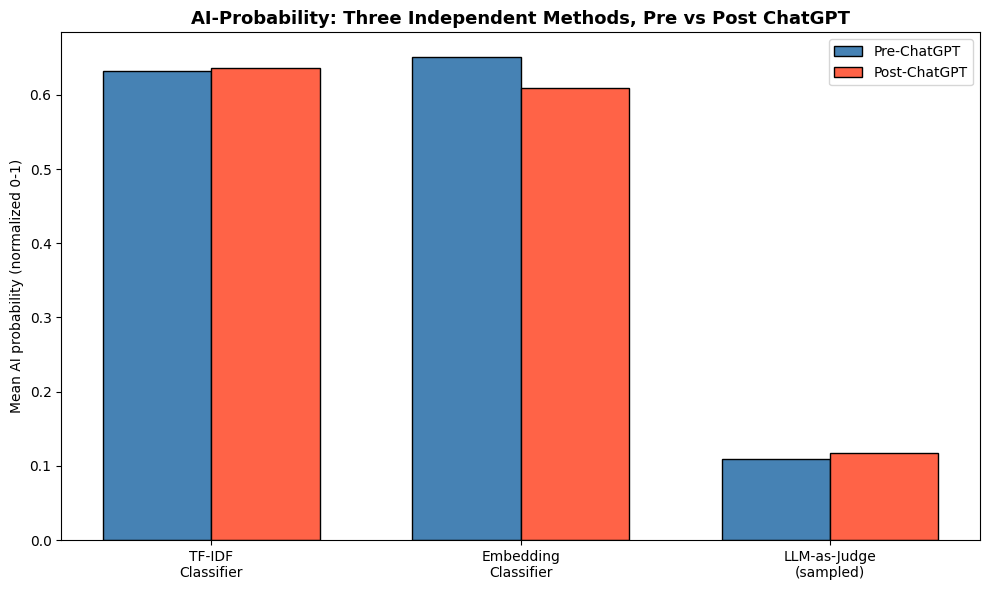

Saved: three_method_comparison.png
 Note: A single classifier finding a small effect could be noise or method artifact.
Three independent methods (bag-of-words, embeddings, and an LLM with no
training on this specific task) pointing the same direction is a much
stronger claim. If they disagree, that itself is a finding worth discussing,
it suggests the original result may be sensitive to how "AI-like" is defined.



In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
methods = ['TF-IDF\nClassifier', 'Embedding\nClassifier', 'LLM-as-Judge\n(sampled)']
pre_vals  = [mean_pre, mean_pre_embed, pre_scores.mean() / 100]
post_vals = [mean_post, mean_post_embed, post_scores.mean() / 100]

x = np.arange(len(methods))
width = 0.35
ax.bar(x - width/2, pre_vals,  width, label='Pre-ChatGPT', color='steelblue', edgecolor='black')
ax.bar(x + width/2, post_vals, width, label='Post-ChatGPT', color='tomato', edgecolor='black')
ax.set_title('AI-Probability: Three Independent Methods, Pre vs Post ChatGPT',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Mean AI probability (normalized 0-1)')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/three_method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: three_method_comparison.png")

print(""" Note: A single classifier finding a small effect could be noise or method artifact.
Three independent methods (bag-of-words, embeddings, and an LLM with no
training on this specific task) pointing the same direction is a much
stronger claim. If they disagree, that itself is a finding worth discussing,
it suggests the original result may be sensitive to how "AI-like" is defined.
""")